# Reprocess a single run -- kinetic energy (from the `.mat`)

Runs `batch_KineticEnergy`'s per-run step for ONE run straight from a PIV `.mat`,
so the outputs are identical to the batch's for that run: the combined
`KineticEnergy_<region>.npz` (time series + both FFT spectra), the two-panel
figure, and the `KineticEnergy_summary_<region>.csv` row (peak + amplitudes at
`f_lib` and `2*f_lib`, from `<FFT(Ek)>`).

Set `PIV_FILENAME` to the PIV `.mat` to reprocess -- this notebook **always** uses
that local name (the `param_postProcessing.json` value is ignored). A band-passed
file (`..._bp<lo>-<hi>Hz.mat` from `filter_velocity_bandpass`) has its
`_bp<lo>-<hi>Hz` tag appended to every output, so the filtered results never
overwrite the raw ones.

Switches: `REPROCESS` re-reads the `.mat` and overwrites the `.npz`/figure (with
`REPROCESS = False`, an existing `.npz` is reused); `UPDATE_SUMMARY` adds/refreshes
this run's summary row.

## 1. Imports

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import pywt
except ImportError:              # only needed when PERFORM_WAVELET
    pywt = None

%matplotlib widget

from piv_postprocessing_lib import (topography_arrangement, amp_at_freq,
                        amp_from_rfft, compute_fft, dimensionless_numbers,
                        fft_axis_limits, figure_filename, libration_ke_scale,
                        libration_velocity_scale, load_piv, parse_run_name,
                        peak_freq, read_acquisition_params, read_paramPostprocessing,
                        region_fields, region_tag)

## 2. Configuration

In [2]:
# --- Mute switch -----------------------------------------------------------
# MUTE_PRINT = True silences ALL print() output (this notebook AND the library),
# so a running batch stays quiet while you edit other files. Re-run this cell to
# toggle. (Figures are unaffected.)
import builtins
if not hasattr(builtins, "_piv_real_print"):
    builtins._piv_real_print = builtins.print
MUTE_PRINT = False
builtins.print = (lambda *a, **k: None) if MUTE_PRINT else builtins._piv_real_print

# ----------------------------------------------------------------------
# USER SETTINGS
# ----------------------------------------------------------------------

# The single run folder to process (must hold the .mat and the acquisition log).
PATH = ('/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/'
        'CylinderExperimentsGMA/k20_topBottom/frot0.50Hz_flib0.410Hz_dphi2deg_SS1')
# Spatial extent: 'ROI' (crop to PTS_ROI) or 'FULL' (whole field). Written into
# every output filename, so the two never overwrite each other.
REGION = 'ROI'

# Per-run output + summary stems (region tag appended) -- identical to the batch.
RESULT_STEM = 'KineticEnergy'          # per-run npz -> <stem>_<region>.npz
FFTFIG_STEM = 'KineticEnergy_FFT'      # per-run 2-panel figure beside the npz
SUMMARY_STEM = 'KineticEnergy_summary' # summary at the dataset root -> <stem>_<region>.csv

# --- Overwrite / output switches -----------------------------------------
REPROCESS      = True   # recompute + overwrite the npz/figure if they exist
UPDATE_SUMMARY = True   # add/refresh this run's row in KineticEnergy_summary_<region>.csv

# --- FFT ------------------------------------------------------------------
DETREND = True   # remove the mean before the FFT (kills the DC spike)
LOGY    = True   # log amplitude axis on the spectrum panel
LOGX    = False  # log frequency axis (False -> linear)

# Saved-figure format: 'png' or 'pdf'. Every figure is written twice
# -- a raw version and a '_normalized' one.
FIG_FORMAT = 'png'

# ----------------------------------------------------------------------
# Parameters live in the dataset folder (PATH's parent) -- same as the batch.
# Band-passed PIV .mat to reprocess -- this notebook ALWAYS uses this local
# file; the PIV_FILENAME in param_postProcessing.json is ignored here. Point it
# at a filter_velocity_bandpass output (..._bp<lo>-<hi>Hz.mat).
PIV_FILENAME = 'PIVlab_results_uncalibrated.mat'

_P = read_paramPostprocessing(os.path.dirname(PATH.rstrip('/')))
k0 = _P.k0
TOP_TOPO, BOTTOM_TOPO = topography_arrangement(PATH)
LOG_FILENAME = _P.LOG_FILENAME
# PIV_FILENAME stays the local band-passed file set above (param value ignored).
# If the PIV file is band-passed (name has a '_bp<lo>-<hi>Hz' tag from
# filter_velocity_bandpass), append that tag to every output name so the
# filtered results never overwrite the raw ones.
_bpm = re.search(r"_bp[-0-9.]+Hz", PIV_FILENAME)
BP_TAG = _bpm.group(0) if _bpm else ""
XSCALE, YSCALE = _P.XSCALE, _P.YSCALE
PTS_ROI = _P.PTS_ROI
UNCAL_SCALE = _P.UNCAL_SCALE
tag = region_tag(REGION)

### Wavelet analysis parameters

All settings for the time-frequency (wavelet) analysis in section 6, kept in their own cell.

In [3]:
# --- Wavelet (time-frequency) analysis settings --------------------------
# The wavelet analysis uses the SAME REGION ('ROI'/'FULL') and BP_TAG as above.
# The CWT is computed on the per-point kinetic-energy time series E_k(t) at
# EVERY grid point, and the amplitude |W E_k| is then averaged over the domain
# -- the time-resolved analog of <FFT(Ek)>. It is a separate product: figures +
# a dedicated .npz are written, but nothing is added to the summary.
#
# PERFORM_WAVELET is the master switch for section 6: False skips the wavelet
# analysis entirely -- no CWT, no .npz, no figures -- and leaves whatever is
# already on disk untouched. The CWT is by far the slowest step here, so turning
# it off is the quick way to re-run only the FFT products. Everything else in
# this cell only matters when it is True.
PERFORM_WAVELET = False

WAVELET         = "cmor1.5-1.0"  # PyWavelets continuous wavelet (complex Morlet:
                                 #  "cmor<B>-<C>", B=bandwidth, C=centre freq).
                                 #  Others: "morl", "mexh", "gaus4", "shan1.0-1.0".
WAVELET_FMIN    = 0.05           # Hz, lowest frequency shown on the map
WAVELET_FMAX    = None           # Hz, highest frequency; None -> Nyquist (fps/2)
WAVELET_NFREQ   = 128            # number of frequency rows (scales)
WAVELET_SPACING = "log"          # 'log' or 'linear' spacing of the frequencies
WAVELET_METHOD  = "fft"          # CWT implementation: 'fft' (fast, recommended)
                                 #  or 'conv' (direct convolution, much slower)
WAVELET_MAX_POINTS = None        # cap on the number of grid points averaged
                                 #  (evenly subsampled) to speed up FULL; None ->
                                 #  use EVERY valid point in the region
WAVELET_LOGF    = True           # log frequency (y) axis
WAVELET_LOGC    = True          # log colour scale for the amplitude
WAVELET_CMAP    = "viridis"
WAVELET_STEM    = "KineticEnergyWavelet"   # per-run npz + figure stem


## 3. Helper functions

In [4]:
# These three helpers are byte-for-byte the batch_KineticEnergy versions, so the
# per-run npz, figure and summary row are identical to what the batch writes.

def compute_fft_per_point(ek_pt, fps, detrend=DETREND):
    """<FFT(Ek)>: FFT at each grid point, THEN average the amplitudes."""
    A = np.asarray(ek_pt, dtype=float)
    n = A.shape[-1]
    freq = np.fft.rfftfreq(n, d=1.0 / fps)
    keep = ~np.all(np.isnan(A), axis=1)
    if not np.any(keep):
        return freq, np.full_like(freq, np.nan), 0
    A = A[keep]
    A = np.where(np.isnan(A), np.nanmean(A, axis=1, keepdims=True), A)
    if detrend:
        A = A - A.mean(axis=1, keepdims=True)
    amp = amp_from_rfft(np.fft.rfft(A, axis=-1), n)
    return freq, np.nanmean(amp, axis=0), int(keep.sum())


LBL_AVG_FIRST = r"$|\mathrm{FFT}(\langle E_k \rangle)|$   average, then FFT"
LBL_FFT_FIRST = r"$\langle |\mathrm{FFT}(E_k)| \rangle$   FFT, then average"


def make_fft_figure(out_png, t, ek, freq, amp_avg, amp_mean, run, flib,
                    frot=None, dphi_deg=None, normalize=False):
    """Two-panel figure (time series + both spectra). Same drawing/saving as
    batch_KineticEnergy.save_fft_figure; returned (not closed) so it also displays."""
    escale = (libration_ke_scale(dphi_deg, flib) if normalize and flib
              and dphi_deg is not None and np.isfinite(dphi_deg) else 1.0)
    fscale = frot if (normalize and frot and np.isfinite(frot)) else 1.0
    ek = ek / escale
    amp_avg = amp_avg / escale
    amp_mean = None if amp_mean is None else amp_mean / escale
    freq = freq / fscale
    _flib = flib / fscale if flib else flib
    _frot = frot / fscale if frot else frot
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(t, ek, color="C0", lw=1)
    axes[0].set_xlabel("time (s)", fontsize=13)
    axes[0].set_ylabel((r"$\langle E_k \rangle(t) / E_{\mathrm{lib}}$" if normalize
                        else r"$\langle E_k \rangle(t)$  (m$^2$/s$^2$)"), fontsize=13)
    axes[0].set_title("Kinetic energy time series", fontsize=14)
    axes[0].grid(True, alpha=0.3)

    plot = axes[1].semilogy if LOGY else axes[1].plot
    if amp_mean is not None:
        plot(freq, amp_mean, color="C2", lw=1, label=LBL_FFT_FIRST)
    plot(freq, amp_avg, color="C1", lw=1, label=LBL_AVG_FIRST)
    axes[1].set_xlabel(r"$f / f_{\mathrm{rot}}$" if normalize else "frequency (Hz)",
                       fontsize=13)
    axes[1].set_ylabel((r"$|\widehat{E_k}| / E_{\mathrm{lib}}$" if normalize
                        else r"$|\widehat{E_k}|$  (m$^2$/s$^2$)"), fontsize=13)
    axes[1].set_title("FFT amplitude spectrum" + ("  (mean removed)" if DETREND else ""),
                      fontsize=14)
    axes[1].grid(True, alpha=0.3, which="both")
    axes[1].legend(fontsize=9)
    curves = [amp_avg] if amp_mean is None else [amp_avg, amp_mean]
    _xmax, _ymin, _ymax = fft_axis_limits(freq, curves, _frot, _flib)
    if LOGX:
        axes[1].set_xscale("log")
        _pos = freq[(freq > 0) & (freq <= _xmax)]
        axes[1].set_xlim(_pos.min() if _pos.size else _xmax / 100.0, _xmax)
    else:
        axes[1].set_xlim(0, _xmax)
    if _ymin and _ymax:
        axes[1].set_ylim(_ymin, _ymax)
    if _flib:
        for fq, lbl in ((_flib, r"$f_{\mathrm{lib}}$"),
                        (2 * _flib, r"$2f_{\mathrm{lib}}$")):
            if fq <= freq.max():
                axes[1].axvline(fq, color="k", ls="--", lw=1, alpha=0.6)
                axes[1].annotate(lbl, xy=(fq, 1), xycoords=("data", "axes fraction"),
                                 xytext=(2, -12), textcoords="offset points", fontsize=10)

    fig.suptitle(run + ("   (normalized)" if normalize else "")
                 + "   ($k_0 = %g$, top=%s, bottom=%s)" % (k0, TOP_TOPO, BOTTOM_TOPO),
                 fontsize=13)
    fig.tight_layout()
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    return fig


def build_row(name, npz_file, fig_file, processed, region=np.nan,
              mean_Ekin=np.nan, std_Ekin=np.nan, dt_vel=np.nan, fps=np.nan,
              nframes=np.nan, npoints=np.nan, ok=np.nan,
              f_peak=np.nan, amp_peak=np.nan, amp_flib=np.nan, amp_2flib=np.nan):
    """One combined summary row -- identical schema to batch_KineticEnergy."""
    frot_hz, flib_hz, dphi_deg = parse_run_name(name)
    fstar = flib_hz / frot_hz if frot_hz else np.nan
    ss = re.search(r"SS(\d+)", name)
    run_idx = int(ss.group(1)) if ss else np.nan
    dl = dimensionless_numbers(frot_hz, flib_hz, dphi_deg)
    fn = frot_hz if np.isfinite(frot_hz) and frot_hz else np.nan
    ke_scale = dl["U0_mps"] ** 2 if np.isfinite(dl["U0_mps"]) and dl["U0_mps"] else np.nan
    row = {"run": name, "run idx": run_idx, "region": region,
           "processed": processed, "frot_Hz": frot_hz, "flib_Hz": flib_hz,
           "dphi_deg": dphi_deg, "fstar": fstar, "flib_star": fstar,
           "calibrated": ok, "dt_vel_s": dt_vel, "fps_Hz": fps,
           "nframes": nframes, "npoints": npoints,
           "mean_Ekin": mean_Ekin, "std_Ekin": std_Ekin,
           "mean_Ekin_star": mean_Ekin / ke_scale,
           "std_Ekin_star": std_Ekin / ke_scale,
           "f_peak_Hz": f_peak, "f_peak_star": f_peak / fn,
           "amp_peak": amp_peak, "amp_peak_star": amp_peak / ke_scale,
           "amp_flib": amp_flib, "amp_flib_star": amp_flib / ke_scale,
           "amp_2flib": amp_2flib, "amp_2flib_star": amp_2flib / ke_scale,
           "top_topo": TOP_TOPO, "bottom_topo": BOTTOM_TOPO,
           "npz": npz_file, "figure": fig_file}
    row.update(dl)
    return row


def update_summary(csv_path, row):
    """Drop any existing row for this run, append the new one, write the CSV."""
    if os.path.isfile(csv_path):
        df = pd.read_csv(csv_path)
        df = df[df["run"] != row["run"]]
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    else:
        df = pd.DataFrame([row])
    df = df.sort_values(["frot_Hz", "flib_Hz", "dphi_deg"]).reset_index(drop=True)
    df.to_csv(csv_path, index=False)
    return df

## 4. Process the run (time series + both FFT spectra + figure)

wrote /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_topBottom/frot0.50Hz_flib0.410Hz_dphi2deg_SS1/PostProcessing/KineticEnergy_ROI.npz
wrote /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_topBottom/frot0.50Hz_flib0.410Hz_dphi2deg_SS1/PostProcessing/KineticEnergy_FFT_ROI.png


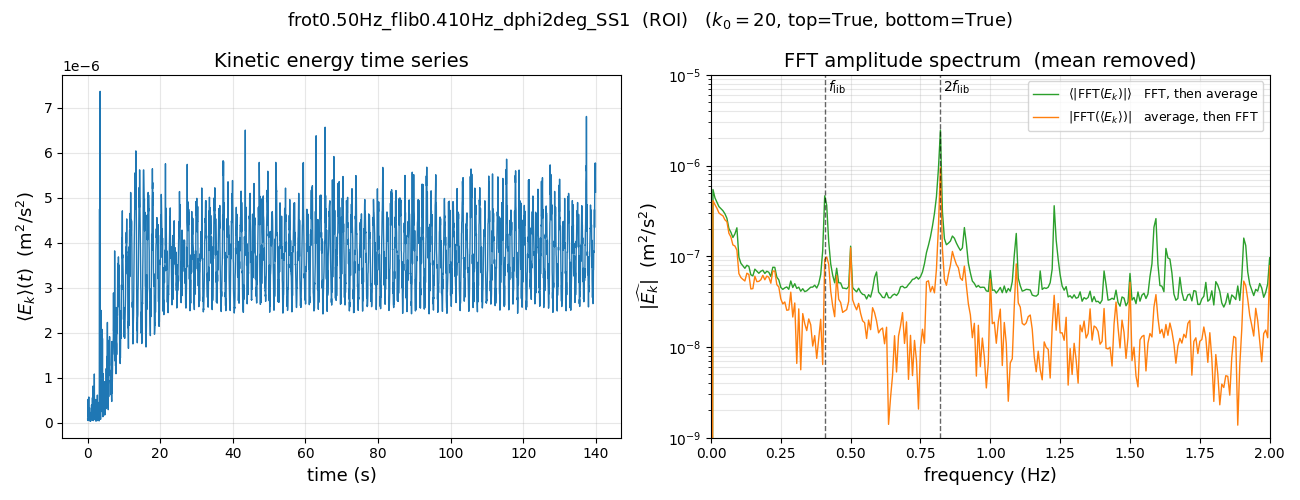

wrote /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_topBottom/frot0.50Hz_flib0.410Hz_dphi2deg_SS1/PostProcessing/KineticEnergy_FFT_ROI_normalized.png


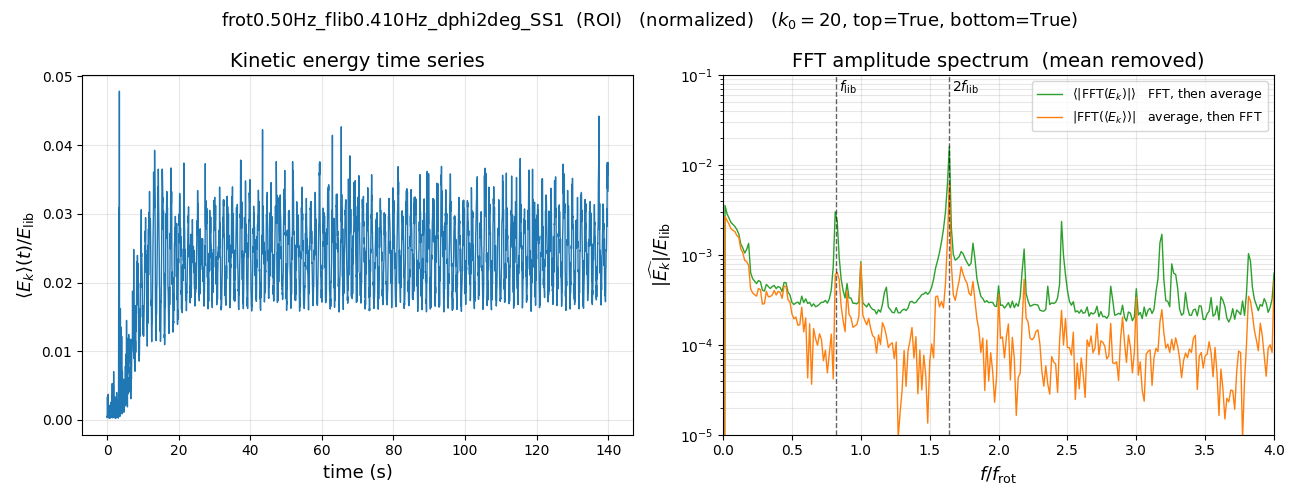

run     : frot0.50Hz_flib0.410Hz_dphi2deg_SS1   (ROI)
<Ek>    : 3.5707e-06   std = 1.0836e-06   f_peak(<FFT(Ek)>) = 0.8214 Hz


In [5]:
# The batch_KineticEnergy per-run step, for this one run + region.
name = os.path.basename(PATH.rstrip("/"))
frot_hz, flib_hz, dphi_deg = parse_run_name(name)
out_dir = os.path.join(PATH, "PostProcessing")
out_file = os.path.join(out_dir, "%s_%s%s.npz" % (RESULT_STEM, tag, BP_TAG))
fig_stem = os.path.join(out_dir, "%s_%s%s" % (FFTFIG_STEM, tag, BP_TAG))
fig_file = figure_filename(fig_stem, FIG_FORMAT, normalized=False)

if os.path.isfile(out_file) and not REPROCESS:
    # Reuse the cached result (exactly like the batch's skip path).
    d = np.load(out_file, allow_pickle=True)
    _g = lambda k: (float(d[k]) if k in d.files else np.nan)
    row = build_row(name, out_file, fig_file, True, region=tag,
                    mean_Ekin=_g("mean_Ekin"), std_Ekin=_g("std_Ekin"),
                    dt_vel=_g("dt_vel"), fps=_g("fps"),
                    nframes=int(d["nframes"]) if "nframes" in d.files else np.nan,
                    npoints=int(d["npoints"]) if "npoints" in d.files else np.nan,
                    ok=bool(d["calibrated"]) if "calibrated" in d.files else np.nan,
                    f_peak=_g("f_peak"), amp_peak=_g("amp_peak"),
                    amp_flib=_g("amp_flib"), amp_2flib=_g("amp_2flib"))
    print("[skip] %s exists and REPROCESS is False -- using cached values"
          % os.path.basename(out_file))
else:
    piv_file = os.path.join(PATH, PIV_FILENAME)
    if not os.path.isfile(piv_file):
        raise FileNotFoundError("no %s in %s" % (PIV_FILENAME, PATH))

    dt_vel, fps, ok = read_acquisition_params(os.path.join(PATH, LOG_FILENAME))
    if ok:
        xscale, yscale = XSCALE, YSCALE
    else:
        print("[warn] Calibration not possible - velocities will be in px/frame")
        xscale = yscale = UNCAL_SCALE

    X, Y, U, V, nframes = load_piv(piv_file)
    X = xscale * X
    Y = yscale * Y
    U = xscale * U / dt_vel
    V = yscale * V / dt_vel
    Xr, Yr, Ur, Vr = region_fields(X, Y, U, V, PTS_ROI, REGION)

    # Per-point Ek(t) over the region, then the region average.
    Ek_pt = 0.5 * (Ur ** 2 + Vr ** 2).reshape(-1, nframes)
    npoints = Ek_pt.shape[0]
    Ek_frame = np.nanmean(Ek_pt, axis=0)
    t = np.arange(nframes) / fps
    mean_Ekin = float(np.nanmean(Ek_frame))
    std_Ekin = float(np.nanstd(Ek_frame))

    U0 = libration_velocity_scale(flib_hz, dphi_deg)
    ke_scale = U0 ** 2 if np.isfinite(U0) and U0 else np.nan
    Ek_frame_star = Ek_frame / ke_scale
    mean_Ekin_star = mean_Ekin / ke_scale
    std_Ekin_star = std_Ekin / ke_scale

    # (1) FFT(<Ek>): average, then FFT.
    freq, amp_avg, _ = compute_fft(Ek_frame, fps, detrend=DETREND)
    # (2) <FFT(Ek)>: FFT at each point, then average -- kept in the summary.
    freq, amp_mean, _npts = compute_fft_per_point(Ek_pt, fps, detrend=DETREND)
    f_peak, amp_peak = peak_freq(freq, amp_mean)
    amp_flib = amp_at_freq(freq, amp_mean, flib_hz)
    amp_2flib = amp_at_freq(freq, amp_mean, 2.0 * flib_hz)

    os.makedirs(out_dir, exist_ok=True)
    np.savez(out_file,
             run=name, PIV_file=piv_file, region=tag, calibrated=ok,
             dt_vel=dt_vel, fps=fps, xscale=xscale, yscale=yscale,
             pts_ROI=np.array(PTS_ROI), npoints=npoints, nframes=nframes,
             t=t, Ek_frame=Ek_frame, Ek_frame_star=Ek_frame_star,
             mean_Ekin=mean_Ekin, std_Ekin=std_Ekin,
             mean_Ekin_star=mean_Ekin_star, std_Ekin_star=std_Ekin_star, U0=U0,
             detrend=DETREND, freq=freq,
             amp_fft_of_mean=amp_avg, amp_mean_of_fft=amp_mean,
             f_peak=f_peak, amp_peak=amp_peak,
             amp_flib=amp_flib, amp_2flib=amp_2flib)
    print("wrote", out_file)

    # Two-panel figure (both spectra), raw and normalized -- identical to batch.
    _flib = None if not np.isfinite(flib_hz) else flib_hz
    _frot = None if not np.isfinite(frot_hz) else frot_hz
    for _norm, _out in ((False, fig_file),
                        (True, figure_filename(fig_stem, FIG_FORMAT, normalized=True))):
        make_fft_figure(_out, t, Ek_frame, freq, amp_avg, amp_mean,
                        "%s  (%s)" % (name, tag), _flib, _frot, dphi_deg,
                        normalize=_norm)
        print("wrote", _out)
        plt.show()

    row = build_row(name, out_file, fig_file, True, region=tag,
                    mean_Ekin=mean_Ekin, std_Ekin=std_Ekin, dt_vel=dt_vel,
                    fps=fps, nframes=nframes, npoints=npoints, ok=ok,
                    f_peak=f_peak, amp_peak=amp_peak, amp_flib=amp_flib,
                    amp_2flib=amp_2flib)

print("run     : %s   (%s)" % (name, tag))
print("<Ek>    : %.4e   std = %.4e   f_peak(<FFT(Ek)>) = %.4g Hz"
      % (row["mean_Ekin"], row["std_Ekin"], row["f_peak_Hz"]))

## 5. Summary

In [6]:
# Add/refresh this run's row in the dataset's single KineticEnergy summary.
# The row is identical to the one batch_KineticEnergy would write for this run.
if UPDATE_SUMMARY:
    base_dir = os.path.dirname(PATH.rstrip("/"))     # dataset root, where the summary lives
    ke_summary_csv = os.path.join(base_dir, "%s_%s%s.csv" % (SUMMARY_STEM, tag, BP_TAG))
    update_summary(ke_summary_csv, row)
    print("updated %s summary:\n   %s" % (tag, ke_summary_csv))
    print()
    for k, v in row.items():
        print("   %-16s %s" % (k, v))
else:
    print("UPDATE_SUMMARY is False -- summary table left untouched.")

updated ROI summary:
   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_topBottom/KineticEnergy_summary_ROI.csv

   run              frot0.50Hz_flib0.410Hz_dphi2deg_SS1
   run idx          1
   region           ROI
   processed        True
   frot_Hz          0.5
   flib_Hz          0.41
   dphi_deg         2.0
   fstar            0.82
   flib_star        0.82
   calibrated       True
   dt_vel_s         0.02
   fps_Hz           25.0
   nframes          3500
   npoints          7030
   mean_Ekin        3.5706723222032364e-06
   std_Ekin         1.08355095038582e-06
   mean_Ekin_star   0.023187271525837983
   std_Ekin_star    0.0070363751785470505
   f_peak_Hz        0.8214285714285714
   f_peak_star      1.6428571428571428
   amp_peak         2.4620278442885897e-06
   amp_peak_star    0.015987943719928878
   amp_flib         4.632736579993257e-07
   amp_flib_star    0.003008411618171204
   amp_2flib        2.4620278442885897e-06
   

## 6. Wavelet analysis (time-frequency of $E_k$)

Continuous wavelet transform of the kinetic-energy time series at every grid point, then averaged over the region (the time-resolved analog of $\langle\mathrm{FFT}(E_k)\rangle$). Produces a scalogram (time on x, frequency on y, amplitude in colour), using the same `REGION` as above. Writes a raw and a normalized figure plus a dedicated `KineticEnergyWavelet_<region>.npz`; **not** added to the summary.

In [7]:
def _interp_nan_1d(x):
    """Linearly interpolate NaNs in a 1-D time series (endpoints held).
    All-NaN (or <2 finite) input is returned as zeros."""
    x = np.asarray(x, dtype=float).copy()
    good = np.isfinite(x)
    if good.sum() < 2:
        return np.nan_to_num(x, nan=0.0)
    idx = np.arange(x.size)
    x[~good] = np.interp(idx[~good], idx[good], x[good])
    return x


def wavelet_analysis_ke(Ek_pt, fps, wavelet=None, fmin=None, fmax=None,
                        nfreq=None, spacing=None, method=None, max_points=None):
    """Per-point continuous wavelet transform of E_k(t), averaged over the region.

    For EVERY grid point of the region, the CWT amplitude |W E_k| of that point's
    kinetic-energy time series is computed, and the result is averaged over all
    valid points -- the time-frequency analog of <FFT(Ek)>, which averages the
    per-point FFT amplitude spectra. `Ek_pt` is (npoints, ntime). NaNs are
    interpolated in time per point; fully masked points (< 2 finite samples) are
    skipped. Points are processed in memory-bounded chunks with the FFT-based CWT.

    Keyword defaults fall back to the WAVELET_* configuration constants.
    Returns (t, freqs, amp, ek_bar, npts): t [s], freqs [Hz] ascending, amp
    (nfreq, ntime) mean over points, ek_bar region-mean E_k(t) (reference), npts.
    """
    wavelet = wavelet or WAVELET
    fmin = WAVELET_FMIN if fmin is None else fmin
    fmax = WAVELET_FMAX if fmax is None else fmax
    nfreq = WAVELET_NFREQ if nfreq is None else nfreq
    spacing = WAVELET_SPACING if spacing is None else spacing
    method = WAVELET_METHOD if method is None else method
    max_points = WAVELET_MAX_POINTS if max_points is None else max_points

    Ek_pt = np.asarray(Ek_pt, dtype=float)
    ntime = Ek_pt.shape[1]

    fhi = fmax if fmax else 0.5 * fps                 # None -> Nyquist
    flo = max(fmin, fps / ntime)                      # can't resolve < ~1 cycle
    if spacing == "linear":
        freqs_req = np.linspace(flo, fhi, nfreq)
    else:
        freqs_req = np.logspace(np.log10(flo), np.log10(fhi), nfreq)
    scales = pywt.frequency2scale(wavelet, freqs_req / fps)

    valid = np.isfinite(Ek_pt).sum(1) >= 2            # need >= 2 finite to interp
    idx = np.where(valid)[0]
    t = np.arange(ntime) / fps
    ek_bar = _interp_nan_1d(np.nanmean(Ek_pt, axis=0))
    if idx.size == 0:
        freqs = pywt.scale2frequency(wavelet, scales) * fps
        order = np.argsort(freqs)
        print("  [wavelet] no valid points -- empty map")
        return t, freqs[order], np.zeros((nfreq, ntime)), ek_bar, 0

    if max_points and idx.size > max_points:
        keep = np.unique(np.linspace(0, idx.size - 1, int(max_points))
                         .round().astype(int))
        idx = idx[keep]
        print("  [wavelet] averaging %d of %d valid points (WAVELET_MAX_POINTS)"
              % (idx.size, int(valid.sum())))
    else:
        print("  [wavelet] averaging over all %d valid points" % idx.size)

    chunk = max(1, int(256e6 / (nfreq * ntime * 16)))  # ~256 MB per CWT block
    acc = np.zeros((nfreq, ntime))
    freqs = None
    done = 0
    for c0 in range(0, idx.size, chunk):
        sel = idx[c0:c0 + chunk]
        ee = np.vstack([_interp_nan_1d(Ek_pt[i]) for i in sel])
        ce, freqs = pywt.cwt(ee, scales, wavelet, sampling_period=1.0 / fps,
                             method=method)
        acc += np.abs(ce).sum(axis=1)
        del ce, ee
        done += sel.size
        print("  [wavelet] %d / %d points done" % (done, idx.size))

    amp = acc / done                                   # mean over points
    order = np.argsort(freqs)                           # ascending for plotting
    freqs = freqs[order]
    amp = amp[order, :]
    return t, freqs, amp, ek_bar, done


def _save_wavelet_figure_ke(out_png, t, freqs, amp, name, fps, flib, frot,
                            ke_scale, normalize=False):
    """Wavelet scalogram of E_k: time on x, frequency on y, amplitude in colour.

    normalize=False -> dimensional (t [s], f [Hz], amp [m^2/s^2]).
    normalize=True  -> non-dimensional (t*f_rot, f/f_rot, amp/E_lib).
    Dashed white lines mark f_lib and 2 f_lib.
    """
    from matplotlib.colors import LogNorm
    _gf = bool(np.isfinite(frot) and frot)
    _gk = bool(np.isfinite(ke_scale) and ke_scale)
    if normalize:
        x = t * frot if _gf else t
        y = freqs / frot if _gf else freqs
        c = amp / ke_scale if _gk else amp
        xlabel = (r"$t\,f_{\mathrm{rot}}$ (rotations)" if _gf else "time (s)")
        ylabel = (r"$f / f_{\mathrm{rot}}$" if _gf else "frequency (Hz)")
        clabel = (r"$\langle|W E_k|\rangle\,/\,E_{\mathrm{lib}}$" if _gk
                  else "amplitude")
    else:
        x, y, c = t, freqs, amp
        xlabel, ylabel = "time (s)", "frequency (Hz)"
        clabel = r"$\langle|W E_k|\rangle$  (m$^2$/s$^2$)"

    finite = c[np.isfinite(c)]
    if WAVELET_LOGC and finite.size and np.any(finite > 0):
        pos = finite[finite > 0]
        norm = LogNorm(vmin=np.nanpercentile(pos, 5),
                       vmax=np.nanpercentile(finite, 99.5))
        vkw = {}
    else:
        norm = None
        vkw = {"vmin": 0.0,
               "vmax": float(np.nanpercentile(finite, 99)) if finite.size else 1.0}

    fig, ax = plt.subplots(figsize=(9.5, 4.8), dpi=150)
    pcm = ax.pcolormesh(x, y, np.ma.masked_invalid(c), cmap=WAVELET_CMAP,
                        shading="nearest", norm=norm, **vkw)
    if WAVELET_LOGF:
        ax.set_yscale("log")
    for _fq, _lab in ((flib, r"$f_{\mathrm{lib}}$"),
                      (2.0 * flib if flib else np.nan, r"$2f_{\mathrm{lib}}$")):
        if _fq and np.isfinite(_fq):
            _yy = (_fq / frot if (normalize and _gf) else _fq)
            ax.axhline(_yy, color="w", ls="--", lw=1.0, alpha=0.8)
            ax.text(x[-1], _yy, " " + _lab, color="w", va="center",
                    ha="left", fontsize=8)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    fig.colorbar(pcm, ax=ax, pad=0.02).set_label(clabel)
    fig.suptitle("%s%s   (%s, $k_0=%g$, top=%s, bottom=%s)%s"
                 % (name, "   (normalized)" if normalize else "", WAVELET, k0,
                    TOP_TOPO, BOTTOM_TOPO, ("   %s" % BP_TAG) if BP_TAG else ""),
                 fontsize=10)
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()
    return fig


In [8]:
# Per-point wavelet analysis of the kinetic energy, averaged over the region
# (same REGION and BP_TAG as above). Writes a dedicated .npz plus a raw and a
# normalized scalogram figure. These results are NOT added to the summary.
if not PERFORM_WAVELET:
    print("[skip] wavelet analysis (PERFORM_WAVELET=False)")
elif pywt is None:
    print("[skip] wavelet analysis: PyWavelets is not installed "
          "(conda install pywavelets)")
else:
    wav_stem = os.path.join(out_dir, "%s_%s%s" % (WAVELET_STEM, tag, BP_TAG))
    wav_npz = wav_stem + ".npz"
    _wav_figs = [figure_filename(wav_stem, FIG_FORMAT, normalized=_n) for _n in (False, True)]

    if (not REPROCESS) and os.path.isfile(wav_npz) and all(os.path.isfile(f) for f in _wav_figs):
        print("[skip] wavelet outputs exist (REPROCESS=False):",
              os.path.basename(wav_npz))
    else:
        # Ensure the per-point KE series + fps exist. The process cell above skips
        # building them when it reuses a cached npz (REPROCESS=False), so rebuild here.
        try:
            Ek_pt        # noqa: F821
            fps          # noqa: F821
        except NameError:
            _dtw, fps, _okw = read_acquisition_params(os.path.join(PATH, LOG_FILENAME))
            _xw, _yw = (XSCALE, YSCALE) if _okw else (UNCAL_SCALE, UNCAL_SCALE)
            _Xw, _Yw, _Uw, _Vw, _nfw = load_piv(os.path.join(PATH, PIV_FILENAME))
            _Xw = _xw * _Xw
            _Yw = _yw * _Yw
            _Uw = _xw * _Uw / _dtw
            _Vw = _yw * _Vw / _dtw
            _, _, _Urw, _Vrw = region_fields(_Xw, _Yw, _Uw, _Vw, PTS_ROI, REGION)
            Ek_pt = 0.5 * (_Urw ** 2 + _Vrw ** 2).reshape(-1, _nfw)
            print("  [wavelet] recomputed Ek_pt from the .mat (cached-skip path)")

        _U0w = libration_velocity_scale(flib_hz, dphi_deg)
        _ke_scale = _U0w ** 2 if (np.isfinite(_U0w) and _U0w) else np.nan

        _wt, _wf, _wamp, _ek_bar, _wnpts = wavelet_analysis_ke(Ek_pt, fps)

        _gf = bool(np.isfinite(frot_hz) and frot_hz)
        _gk = bool(np.isfinite(_ke_scale) and _ke_scale)
        np.savez(wav_npz,
                 run=name, region=tag, wavelet=WAVELET, fps=fps, bp_tag=BP_TAG,
                 flib=flib_hz, frot=frot_hz, dphi=dphi_deg,
                 U0=_U0w, E_lib=_ke_scale, npoints=_wnpts,
                 t=_wt, freq=_wf, amp=_wamp,
                 t_star=(_wt * frot_hz if _gf else np.full_like(_wt, np.nan)),
                 f_star=(_wf / frot_hz if _gf else np.full_like(_wf, np.nan)),
                 amp_star=(_wamp / _ke_scale if _gk else np.full_like(_wamp, np.nan)),
                 ek_bar=_ek_bar)
        print("wrote", wav_npz)

        for _norm, _wp in zip((False, True), _wav_figs):
            _save_wavelet_figure_ke(_wp, _wt, _wf, _wamp, name, fps, flib_hz, frot_hz,
                                    _ke_scale, normalize=_norm)
            print("wrote", _wp)

        print("  [ok] KE wavelet: %d points averaged, amp map %s"
              % (_wnpts, _wamp.shape))


[skip] wavelet analysis (PERFORM_WAVELET=False)
